In [5]:
import numpy as np
import matplotlib.pyplot as plt

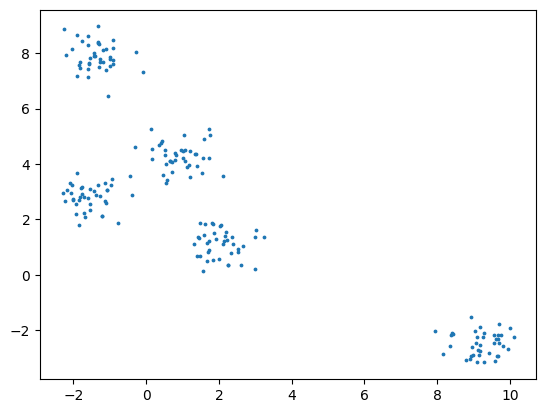

In [6]:
from sklearn.datasets import make_blobs
X, y = make_blobs(
    n_samples=200, 
    n_features=2, 
    centers=5, 
    cluster_std=0.5,
    random_state=0,
    )

plt.scatter(X[:, 0], X[:, 1], s=3)
plt.show()

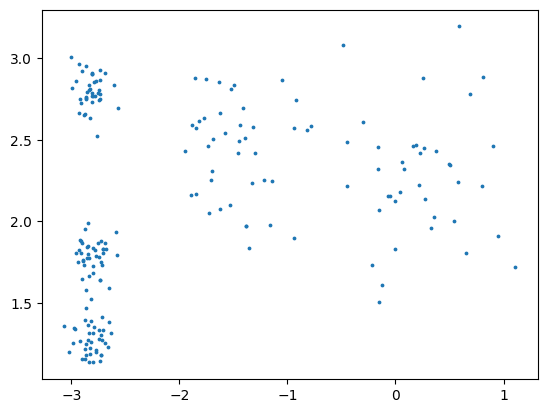

In [7]:
blob_center = np.array([
    [ 0.2,  2.3], 
	[-1.5,  2.3], 
	[-2.8,  1.8],
	[-2.8,  2.8], 
	[-2.8,  1.3]
])

blob_std = np.array(
    [0.4, 0.3, 0.1, 0.1, 0.1]
)

X, y = make_blobs(
    n_samples=200, 
    n_features=2, 
    centers=blob_center, 
    cluster_std=blob_std,
    random_state=0,
    )

plt.scatter(X[:, 0], X[:, 1], s=3)
plt.show()

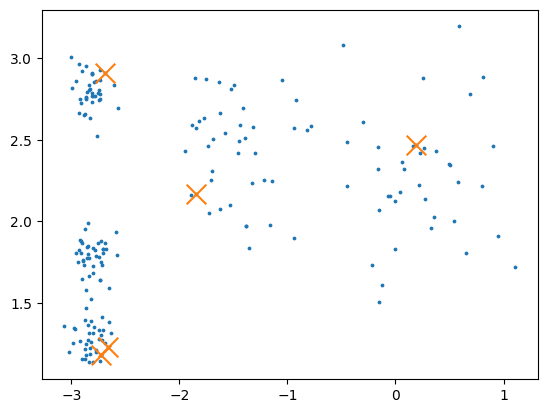

In [8]:
K = 5

rng = np.random.default_rng(137)
centroids = rng.choice(X, size=K, replace=False)

plt.scatter(X[:, 0], X[:, 1], s=3)
plt.scatter(centroids[:, 0], centroids[:, 1], 
            marker='x', s=200)
plt.show()

In [9]:
rng = np.random.default_rng(136)

def initialize_centroid(X, K, rng):

	centroids = rng.choice(X, size=K, replace=False)

	return centroids

initialize_centroid(X, 5, rng)

array([[-2.69003404,  1.86552637],
       [-0.12525851,  1.60948696],
       [-1.73097482,  2.46177476],
       [-1.63054607,  2.85477912],
       [-2.7476109 ,  2.80884221]])

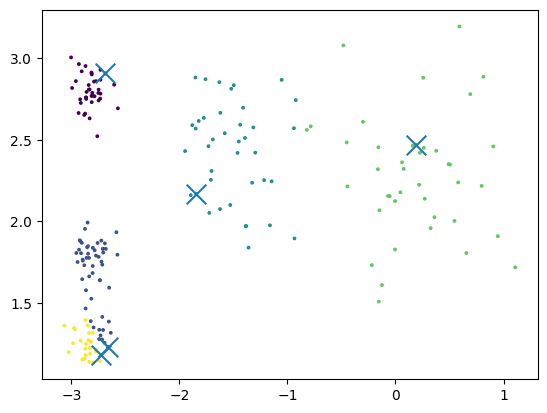

In [10]:
from sklearn.metrics import pairwise_distances, pairwise_distances_argmin
# pairwise_distances(X, centroids).round(2)
y_pred = pairwise_distances_argmin(X, centroids)

plt.scatter(X[:, 0], X[:, 1], s=3, c=y_pred)
plt.scatter(centroids[:, 0], centroids[:, 1],
            marker='x', s=200)
plt.show()

In [11]:
def assign_clusters(X, centroids):
	y_pred = pairwise_distances_argmin(X, centroids)

	return y_pred

assign_clusters(X, centroids)

array([3, 4, 3, 1, 1, 3, 3, 4, 4, 3, 0, 4, 0, 2, 0, 4, 2, 4, 2, 1, 0, 2,
       2, 0, 0, 2, 1, 1, 3, 2, 2, 3, 0, 2, 1, 1, 0, 4, 4, 3, 3, 2, 2, 0,
       0, 1, 4, 1, 3, 1, 1, 3, 0, 2, 0, 1, 4, 4, 2, 0, 0, 4, 1, 2, 4, 2,
       2, 0, 3, 1, 1, 1, 1, 0, 0, 3, 4, 2, 3, 3, 4, 2, 2, 1, 0, 0, 3, 1,
       2, 3, 0, 1, 1, 1, 3, 4, 3, 0, 3, 1, 3, 3, 1, 3, 4, 2, 0, 0, 3, 4,
       2, 1, 1, 1, 1, 1, 2, 3, 0, 0, 0, 2, 1, 4, 1, 2, 1, 3, 2, 2, 2, 3,
       1, 0, 0, 3, 0, 1, 3, 0, 1, 2, 1, 1, 0, 4, 3, 1, 1, 1, 2, 3, 0, 4,
       2, 2, 1, 1, 1, 1, 3, 1, 3, 0, 0, 4, 2, 1, 2, 2, 2, 1, 4, 1, 3, 0,
       2, 3, 2, 4, 4, 0, 1, 1, 2, 4, 1, 1, 0, 3, 3, 3, 3, 0, 1, 0, 3, 1,
       3, 0])

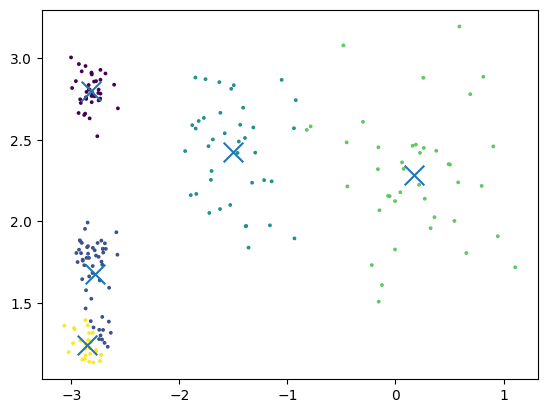

In [12]:
new_centroids = []

for i in range(K):
    new_centroid = X[y_pred == i].mean(axis=0)
    new_centroids.append(new_centroid)
    
new_centroids = np.array(new_centroids)

plt.scatter(X[:, 0], X[:, 1], s=3, c=y_pred)
plt.scatter(new_centroids[:, 0], new_centroids[:, 1],
            marker='x', s=200)
plt.show()

In [13]:
def update_centroids(X, y_pred, K):

	new_centroids = []

	for i in range(K):
		new_centroid = X[y_pred == i].mean(axis=0)
		new_centroids.append(new_centroid)
		
	new_centroids = np.array(new_centroids)

	return new_centroids

update_centroids(X, y_pred, 5)

array([[-2.81954677,  2.80136085],
       [-2.7854639 ,  1.67511835],
       [-1.50716662,  2.42791043],
       [ 0.1725073 ,  2.28653987],
       [-2.85973275,  1.23996054]])

array([[ 0.12917995,  2.02328376],
       [-2.80960127,  1.53369206],
       [-2.81954677,  2.80136085],
       [-1.47282319,  2.43495849],
       [ 0.3314596 ,  2.56191025]])

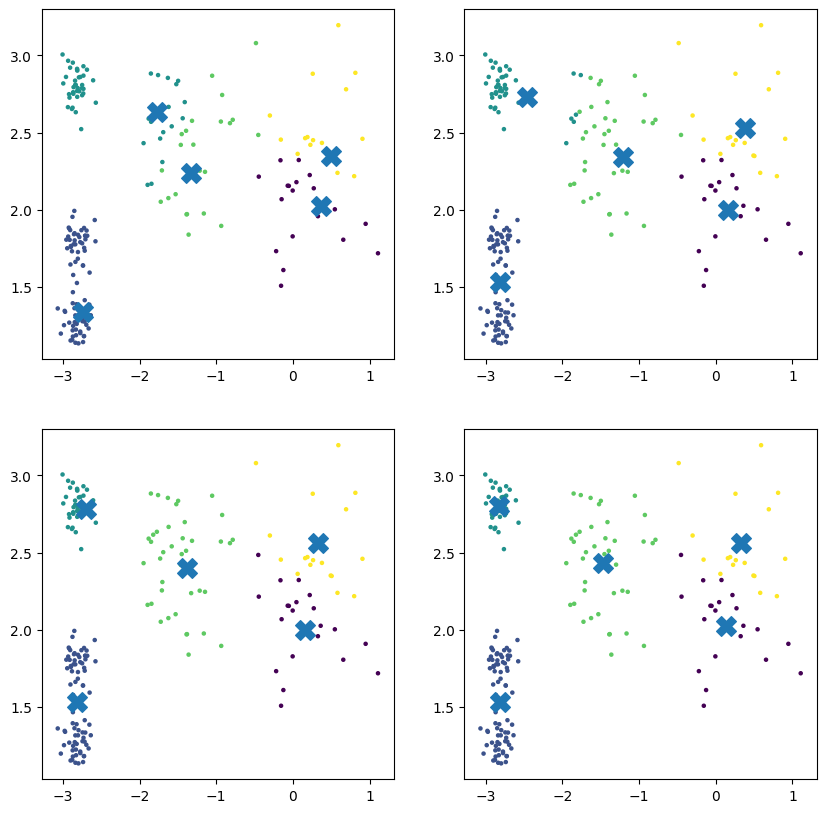

In [14]:
max_iter = 4
K=5
rng = np.random.default_rng(139)
centroids = initialize_centroid(X,K,rng)

fig, axs = plt.subplots(2,2, figsize=(10,10))

for j in range(max_iter):
	y_pred = assign_clusters(X, centroids)
	new_centroids = update_centroids(X, y_pred, K)

	axs.flatten()[j].scatter(X[:, 0], X[:, 1], s=5, c=y_pred)
	axs.flatten()[j].scatter(centroids[:, 0], centroids[:, 1], s=200, marker='X')
    
	centroids = new_centroids

centroids

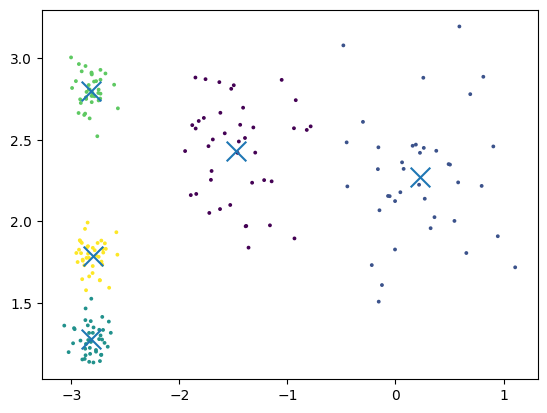

In [15]:
from sklearn.cluster import KMeans
km = KMeans(n_clusters=5, random_state =10)
y_pred = km.fit_predict(X)


plt.scatter(X[:, 0], X[:, 1], s=3, c=y_pred)
plt.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
            marker='x', s=200)
plt.show()

In [16]:
X,y

(array([[ 1.10790185,  1.71825373],
        [-2.77254836,  1.21090849],
        [ 0.22660689,  2.42098876],
        [-2.92254355,  1.8844363 ],
        [-2.88034097,  1.73104502],
        [ 0.58003537,  2.23945712],
        [-0.48250808,  3.08031016],
        [-2.83646935,  1.31567039],
        [-2.79613694,  1.13432849],
        [ 0.81311169,  2.88774351],
        [-2.73101818,  2.93018462],
        [-2.91573553,  1.26877077],
        [-2.81359497,  2.91368914],
        [-1.73097482,  2.46177476],
        [-2.56960833,  2.69399842],
        [-2.96981058,  1.33872805],
        [-1.82122579,  2.61633552],
        [-2.86522936,  1.24788107],
        [-1.52953576,  2.10095651],
        [-2.69314906,  1.25466142],
        [-2.7902275 ,  2.85829537],
        [-1.21582441,  2.25349697],
        [-0.93973231,  2.5718134 ],
        [-2.8309013 ,  2.63239962],
        [-2.77136563,  2.86088438],
        [-1.63054607,  2.85477912],
        [-2.8739563 ,  1.95430146],
        [-2.74767233,  1.782

In [17]:
from pathlib import Path
import pandas as pd

housing_csv_path = Path("/home/admin123/Documents/SAP/Div_academy/data/housing.csv")
df = pd.read_csv(housing_csv_path)
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [18]:
outlier1 = df['housing_median_age'] == df['housing_median_age'].max()
outlier2 = df['median_house_value'] == df['median_house_value'].max()

df = df.loc[~outlier1 & ~outlier2, :]
df.head(2)

from sklearn.model_selection import train_test_split

X['income_cat'] = pd.cut(
    X['median_income'], 
    bins=[0,2,4,6,8,np.inf],
    labels=[1,2,3,4,5],
)

X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.15,
    stratify=df['income_cat']
    )

X_train.drop('income_cat', axis='columns', inplace=True)
X_test.drop('income_cat', axis='columns', inplace=True)
X_train.shape , X_test.shape

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices